Flight Price Prediction

In [4]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder,FunctionTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression


In [5]:
df = pd.read_csv("Flights_data.csv")

In [6]:
df.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_in_mins
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,130
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,140
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,130
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,135
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,140


In [7]:
df1 = df.copy()
df1.drop("Unnamed: 0",axis = 1, inplace = True)
df1.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,duration_in_mins
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,130
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,140
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,130
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,135
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,140


In [8]:
df1.drop('duration',axis = 1, inplace = True)
df1.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,days_left,price,duration_in_mins
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,1,5953,130
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,1,5953,140
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,1,5956,130
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,1,5955,135
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,1,5955,140


In [9]:
df1.drop('stops',axis = 1, inplace = True)
df1.drop('duration_in_mins',axis = 1, inplace = True)
df1.drop('flight',axis = 1, inplace = True)

df1.head()

,airline,source_city,departure_time,arrival_time,destination_city,class,days_left,price
0,SpiceJet,Delhi,Evening,Night,Mumbai,Economy,1,5953
1,SpiceJet,Delhi,Early_Morning,Morning,Mumbai,Economy,1,5953
2,AirAsia,Delhi,Early_Morning,Early_Morning,Mumbai,Economy,1,5956
3,Vistara,Delhi,Morning,Afternoon,Mumbai,Economy,1,5955
4,Vistara,Delhi,Morning,Morning,Mumbai,Economy,1,5955


In [10]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           300153 non-null  object
 1   source_city       300153 non-null  object
 2   departure_time    300153 non-null  object
 3   arrival_time      300153 non-null  object
 4   destination_city  300153 non-null  object
 5   class             300153 non-null  object
 6   days_left         300153 non-null  int64 
 7   price             300153 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 18.3+ MB


In [11]:
df1.isnull().sum()

airline             0
source_city         0
departure_time      0
arrival_time        0
destination_city    0
class               0
days_left           0
price               0
dtype: int64

In [12]:
df1["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

In [13]:
df1.duplicated().sum()

np.int64(75640)

In [14]:
df1.drop_duplicates(inplace = True)

In [15]:
df1.duplicated().sum()

np.int64(0)

In [16]:
df1['departure_time'].value_counts()

departure_time
Morning          53022
Early_Morning    50297
Evening          46251
Night            37414
Afternoon        36290
Late_Night        1239
Name: count, dtype: int64

In [17]:
df1['destination_city'].value_counts()

destination_city
Delhi        43293
Mumbai       43152
Kolkata      37827
Bangalore    36172
Hyderabad    32972
Chennai      31097
Name: count, dtype: int64

In [18]:
df1['source_city'].value_counts()

source_city
Delhi        46505
Mumbai       43928
Kolkata      36713
Bangalore    35618
Hyderabad    31787
Chennai      29962
Name: count, dtype: int64

In [19]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 224513 entries, 0 to 300152
Data columns (total 8 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   airline           224513 non-null  object
 1   source_city       224513 non-null  object
 2   departure_time    224513 non-null  object
 3   arrival_time      224513 non-null  object
 4   destination_city  224513 non-null  object
 5   class             224513 non-null  object
 6   days_left         224513 non-null  int64 
 7   price             224513 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 15.4+ MB


EDA

<Axes: xlabel='price', ylabel='Density'>

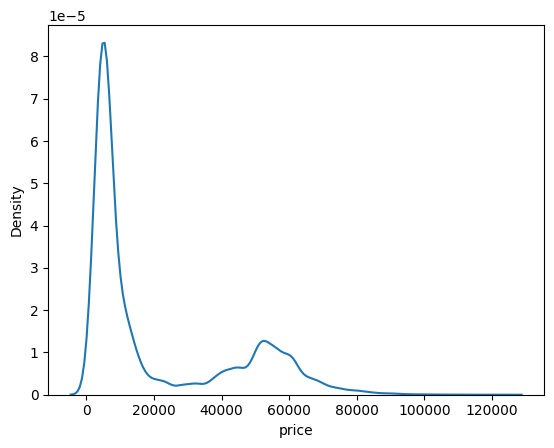

In [20]:
sns.kdeplot(data = df1, x = 'price')

Applying Log transormation to the target column

In [21]:
df1['price'] = np.log1p(df1['price'])

<Axes: xlabel='price', ylabel='Density'>

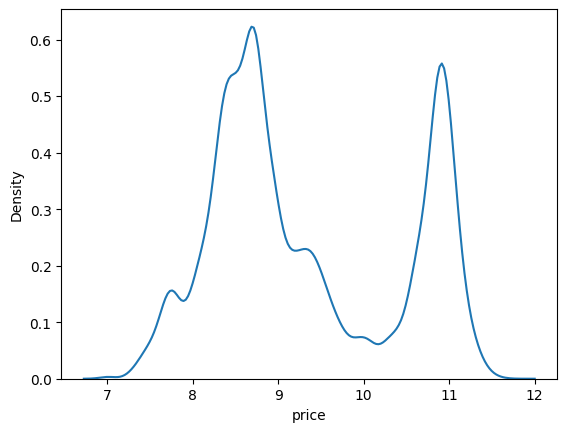

In [22]:
sns.kdeplot(data = df1, x = 'price')

In [23]:
df1[['days_left','price']].corr()

,days_left,price
days_left,1.000000,-0.201547
price,-0.201547,1.000000


Indigo is the most popular airline

In [24]:
df_grouped2 = df1.groupby(['airline','class'], as_index = False).count()
df_grouped2['class'].value_counts()

class
Economy     6
Business    2
Name: count, dtype: int64

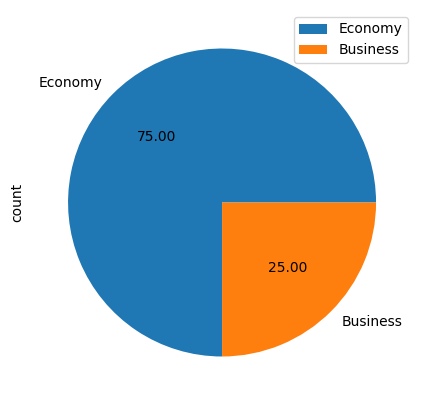

In [25]:
plt.figure(figsize = (8,5))
df_grouped2['class'].value_counts().plot(kind = 'pie', autopct = "%.2f")
plt.legend(['Economy','Business'])
plt.show()

How does the ticket price vary between Economy and Business class?

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\412344583.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="class", y="price",palette = "Set1")


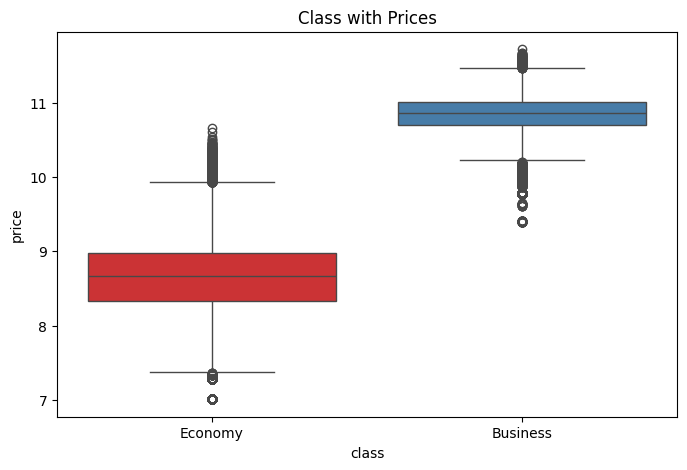

In [26]:
plt.figure(figsize = (8,5))
sns.boxplot(data=df1, x="class", y="price",palette = "Set1")
plt.title("Class with Prices")
plt.show()

variation in ticket price for different airlines.

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\122286678.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="airline", y="price",palette = "Set1")


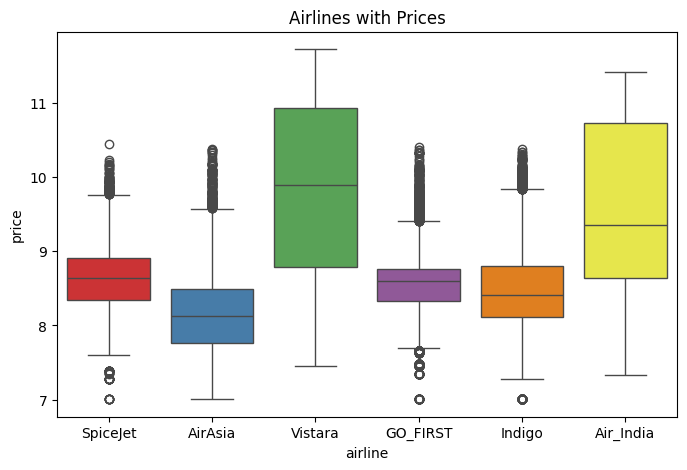

In [27]:
plt.figure(figsize = (8,5))
sns.boxplot(data=df1, x="airline", y="price",palette = "Set1")
plt.title("Airlines with Prices")
plt.show()

Vistara and Air India is the most expensive price when compared to other airline companies

change in price with change in source city and Destination city

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\1767023275.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="source_city", y="price",palette = 'Set1')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\1767023275.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="destination_city", y="price",palette = 'Set1')


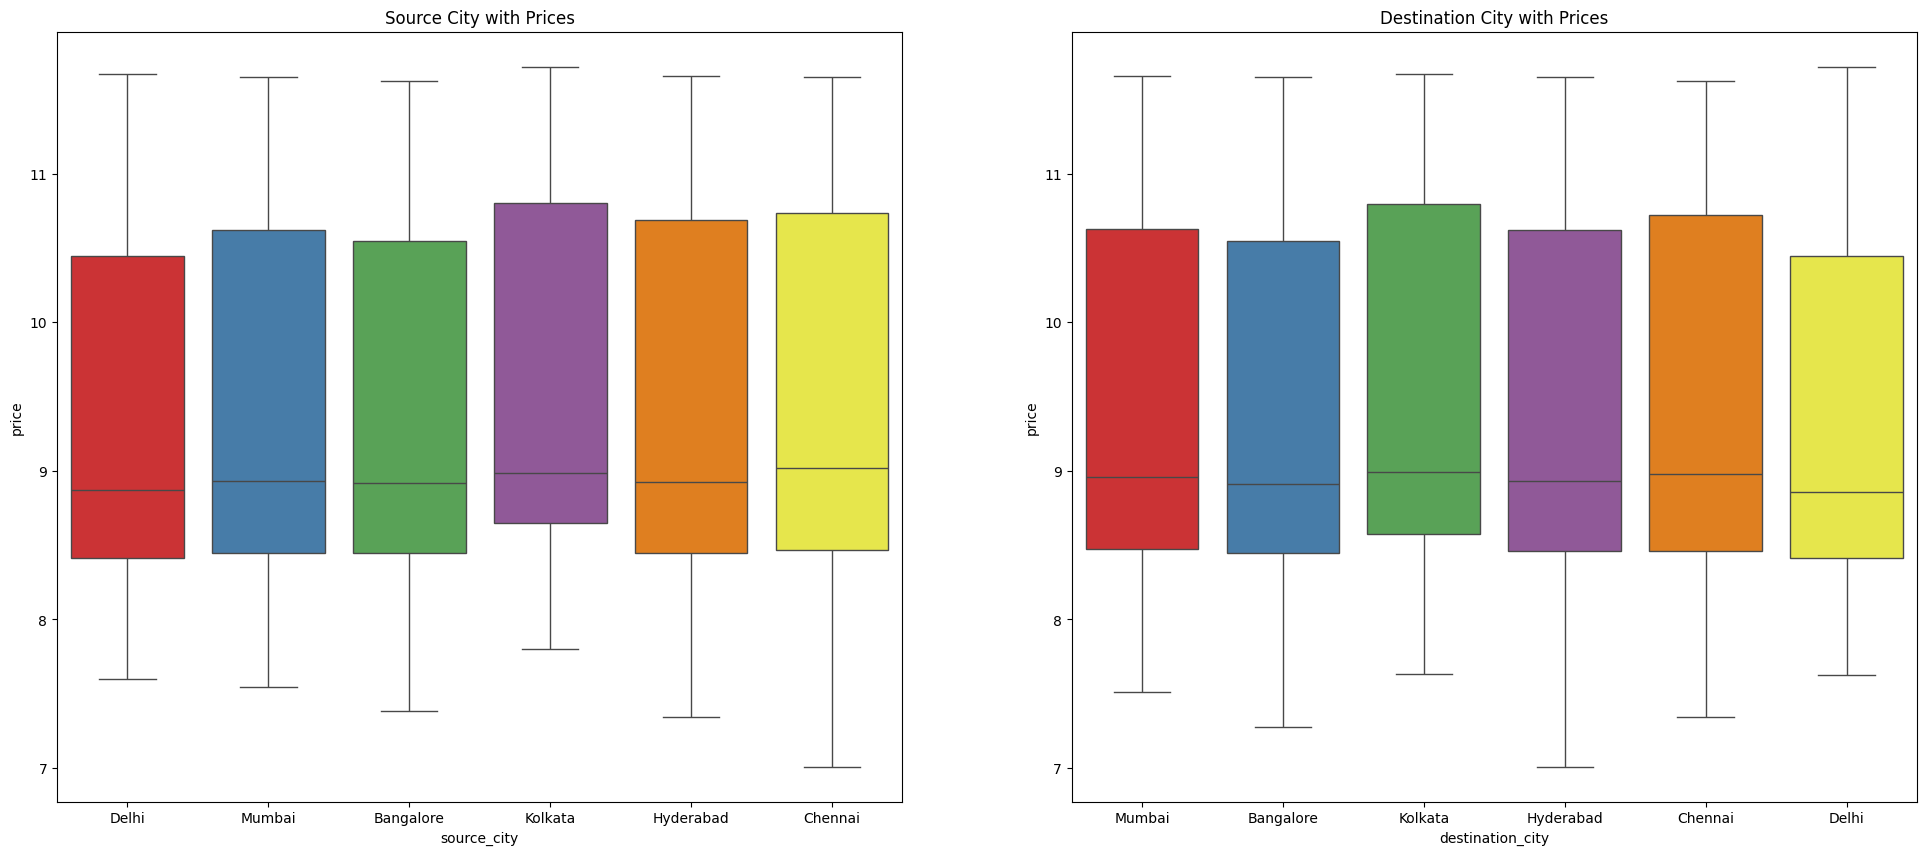

In [28]:
plt.figure(figsize = (24,10))
plt.subplot(1,2,1)
sns.boxplot(data=df1, x="source_city", y="price",palette = 'Set1')
plt.title("Source City with Prices")
plt.subplot(1,2,2)
sns.boxplot(data=df1, x="destination_city", y="price",palette = 'Set1')
plt.title("Destination City with Prices")
plt.show()

change in ticket price based on the departure time

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\1308021548.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="departure_time", y="price",palette = 'Set1')
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\1308021548.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df1, x="arrival_time", y="price",palette = 'Set1')


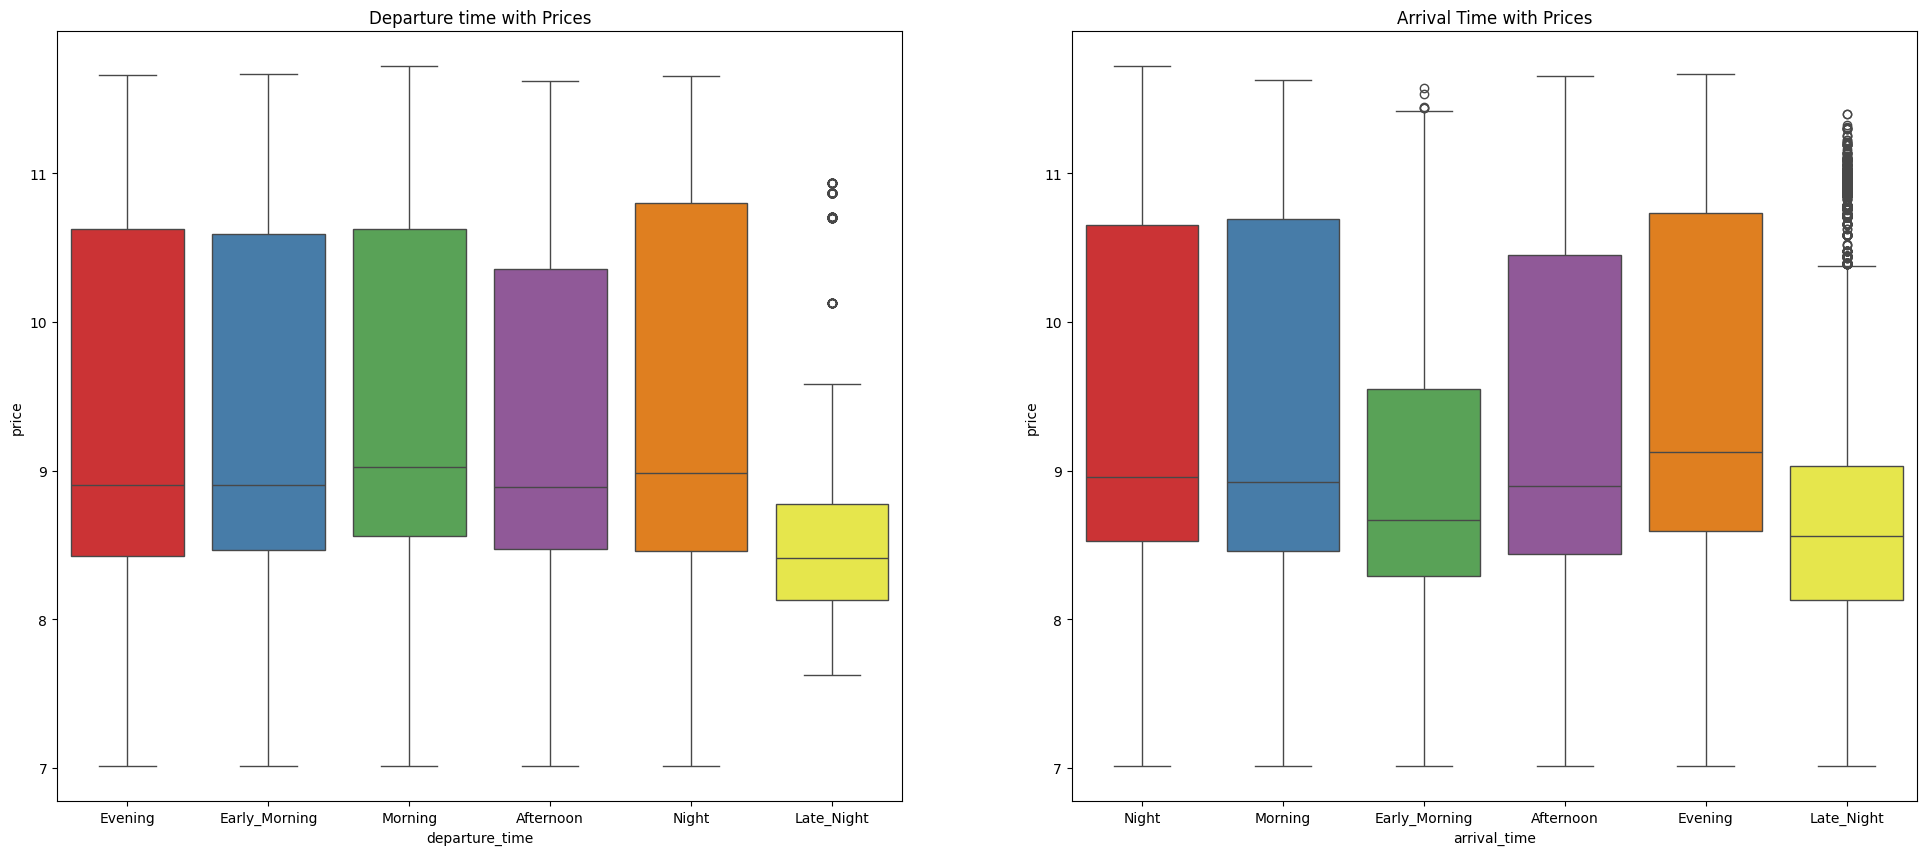

In [29]:
plt.figure(figsize = (24,10))
plt.subplot(1,2,1)
sns.boxplot(data=df1, x="departure_time", y="price",palette = 'Set1')
plt.title("Departure time with Prices")
plt.subplot(1,2,2)
sns.boxplot(data=df1, x="arrival_time", y="price",palette = 'Set1')
plt.title("Arrival Time with Prices")
plt.show()

How is the price affected on the days left for departure?

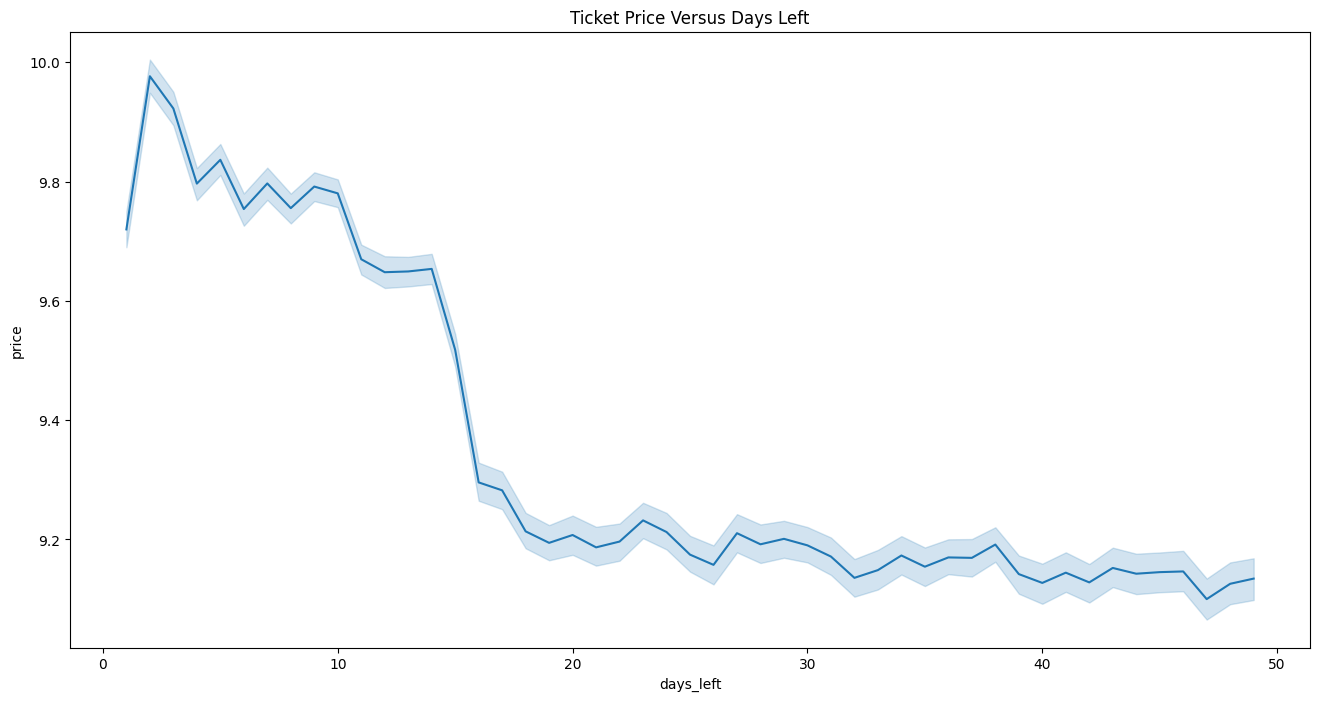

In [30]:
plt.figure(figsize = (16, 8))
sns.lineplot(data = df1, x = 'days_left', y= 'price')
plt.title('Ticket Price Versus Days Left')
plt.show()

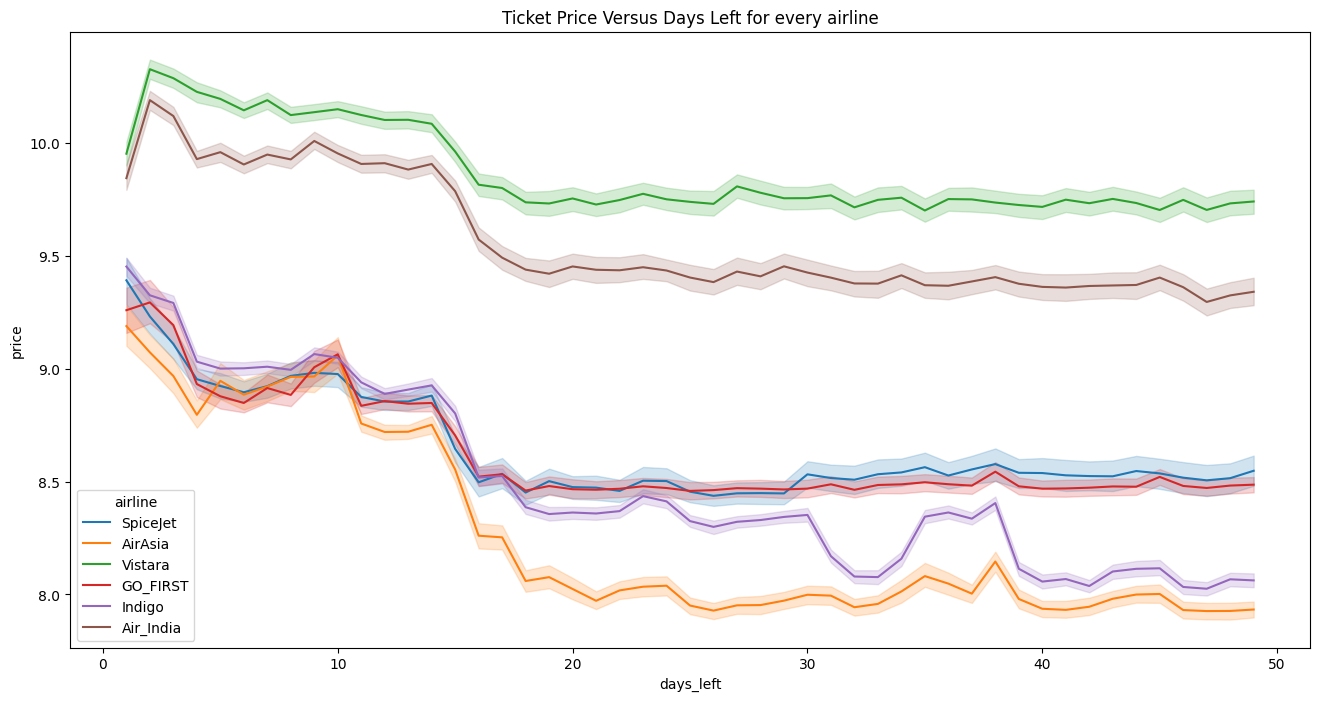

In [31]:
plt.figure(figsize = (16, 8))
sns.lineplot(data = df1, x = 'days_left', y= 'price', hue = 'airline')
plt.title('Ticket Price Versus Days Left for every airline')
plt.show()

Average price of different airlines from source city to destination city

In [32]:
df1.groupby(['airline','source_city','destination_city'], as_index = False)['price'].mean().head()

,airline,source_city,destination_city,price
0,AirAsia,Bangalore,Chennai,7.582930
1,AirAsia,Bangalore,Delhi,8.462589
2,AirAsia,Bangalore,Hyderabad,7.845356
3,AirAsia,Bangalore,Kolkata,8.333866
4,AirAsia,Bangalore,Mumbai,8.023648


In [33]:
X = df1.drop(columns =['price'])
y = df1['price']

In [34]:
X_train,X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state = 1)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16684\2164915367.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1['price'])


<Axes: xlabel='price', ylabel='Density'>

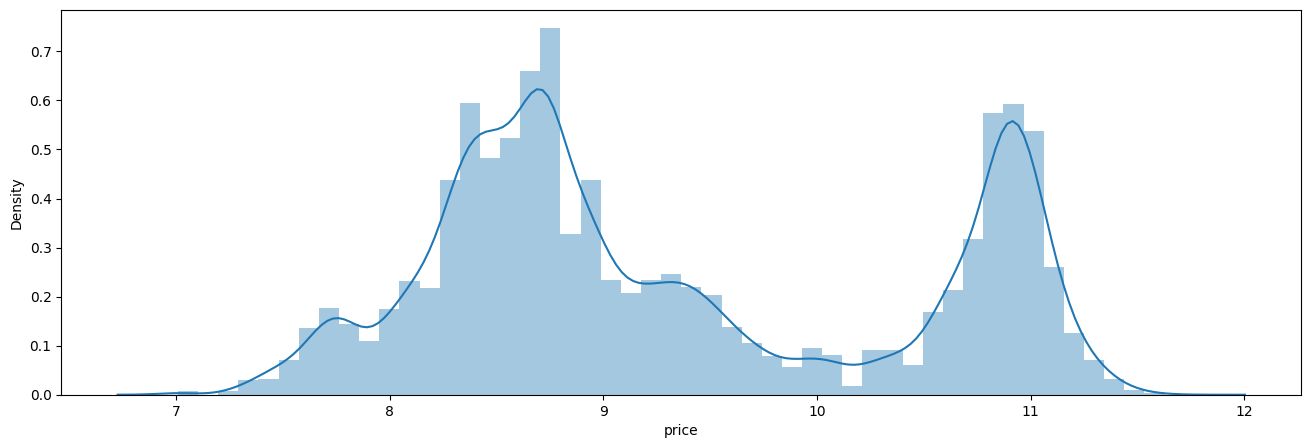

In [35]:
plt.figure(figsize=(16,5))
sns.distplot(df1['price'])

In [36]:
categories = ['airline','source_city','departure_time',"arrival_time",'destination_city','class']

In [37]:
from sklearn.compose import ColumnTransformer

transformer = ColumnTransformer(transformers= [
    ('categories_transform',OneHotEncoder(handle_unknown='ignore',sparse_output=False),categories) # onehot encoding categorical features
],remainder = 'passthrough')

In [38]:
from sklearn.pipeline import Pipeline
pipeline = Pipeline(steps = [
    ('transformer',transformer),
    ('model', LinearRegression())
]).set_output(transform="pandas")

In [39]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('categories_transform',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['airline', 'source_city',
                                                   'departure_time',
                                                   'arrival_time',
                                                   'destination_city',
                                                   'class'])])),
                ('model', LinearRegression())])

In [40]:
y_pred = pipeline.predict(X_test)

In [41]:
mean_squared_error(y_test, y_pred)

0.14219117128214315

In [42]:
r2 = r2_score(y_test, y_pred)
print(f'R² Score: {r2:.5f}')

R² Score: 0.88300


In [43]:
train_r2 = pipeline.score(X_train, y_train)
print(f"Train R² Score: {train_r2:.5f}")

Train R² Score: 0.88379


In [44]:
from sklearn.model_selection import cross_val_score

cv_r2 = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='r2')
print(f"Cross-Validation R² Scores: {cv_r2}")
print(f"Average R² Score: {cv_r2.mean():.5f}")

Cross-Validation R² Scores: [0.88466489 0.88396959 0.88325112 0.88410882 0.88271193]
Average R² Score: 0.88374


In [45]:
import joblib
joblib.dump(pipeline, "model.pkl")


['model.pkl']

In [46]:
ans = joblib.load(open('model.pkl','rb'))